# High-z Example 18: Local Dwarf Progenitor Candidates (EPS)

**EPS Research — Cross-Corpus**

Which Z1 galaxies could be progenitors of local dwarfs?
Criteria: Vmax < 100 km/s, ROT or UNC class, log M* < 10.

ALPINE selection bias means true DDO161-mass progenitors
(log M* ~ 7.5) are below ALPINE detection limits.
The candidates here are upper-mass analogs.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.20369285  
**arXiv:** 2605.25339  
**Source:** Jones et al. (2021), MNRAS 507, 3540; Le Fevre et al. (2020)  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
import json, numpy as np, matplotlib.pyplot as plt

with open('high_z_kinematic_corpus_Z1.json') as f:
    corpus = json.load(f)

# Z1 progenitor candidates
candidates = [g for g in corpus['galaxies']
              if g.get('vrot_max_kms') and g['vrot_max_kms'] < 120
              and g.get('log_mstar_msun') and g['log_mstar_msun'] < 10.5]

print(f"Z1 progenitor candidates (Vmax<120, log M*<10.5): {len(candidates)}")
print(f"\n{'Galaxy':<20} {'z':>7} {'Vmax':>7} {'log M*':>8} {'Class':>6}")
print('-'*55)
for g in sorted(candidates, key=lambda x: x['vrot_max_kms']):
    print(f"{g['galaxy']:<20} {g['redshift']:>7.4f} "
          f"{g['vrot_max_kms']:>7.1f} {g['log_mstar_msun']:>8.2f} "
          f"{g['class_jones2021']:>6}")

print(f"\nComparison — Local dwarfs (EPS Dwarf Corpus v1.0):")
print(f"  DDO161: Vmax=67 km/s, log M*~7.8")
print(f"  Median dwarf: Vmax~50 km/s")
print(f"  Note: ALPINE misses true DDO161-mass progenitors (ALPINE SFR > few Msun/yr)")

Z1 progenitor candidates (Vmax<120, log M*<10.5): 4

Galaxy                     z    Vmax   log M*  Class
-------------------------------------------------------
DC494057              5.5446    80.3    10.00    ROT
DC881725              4.5778    98.4    10.00    ROT
CG32                  4.4105   117.4    10.20    ROT
VC5110377875          4.5506   119.0    10.20    ROT

Comparison — Local dwarfs (EPS Dwarf Corpus v1.0):
  DDO161: Vmax=67 km/s, log M*~7.8
  Median dwarf: Vmax~50 km/s
  Note: ALPINE misses true DDO161-mass progenitors (ALPINE SFR > few Msun/yr)


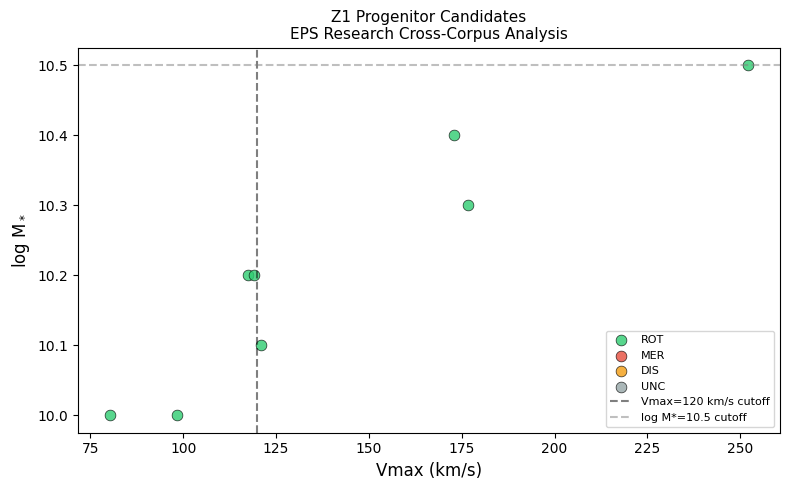

In [2]:
all_g = corpus['galaxies']
vmax  = [g['vrot_max_kms'] for g in all_g if g.get('vrot_max_kms')]
ms    = [g['log_mstar_msun'] for g in all_g if g.get('vrot_max_kms') and g.get('log_mstar_msun')]
vmax2 = [g['vrot_max_kms'] for g in all_g if g.get('vrot_max_kms') and g.get('log_mstar_msun')]
classes=[g['class_jones2021'] for g in all_g if g.get('vrot_max_kms') and g.get('log_mstar_msun')]

COLORS={'ROT':'#2ecc71','MER':'#e74c3c','DIS':'#f39c12','UNC':'#95a5a6'}
fig,ax=plt.subplots(figsize=(8,5))
for cls,color in COLORS.items():
    idx=[i for i,c in enumerate(classes) if c==cls]
    ax.scatter([vmax2[i] for i in idx],[ms[i] for i in idx],
               s=60,color=color,label=cls,alpha=0.8,edgecolors='k',linewidths=0.5)
ax.axvline(120,color='black',ls='--',lw=1.5,alpha=0.5,label='Vmax=120 km/s cutoff')
ax.axhline(10.5,color='gray',ls='--',lw=1.5,alpha=0.5,label='log M*=10.5 cutoff')
ax.set_xlabel('Vmax (km/s)',fontsize=12); ax.set_ylabel(r'log M$_*$',fontsize=12)
ax.set_title('Z1 Progenitor Candidates\nEPS Research Cross-Corpus Analysis',fontsize=11)
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig('hz18_progenitors.png',dpi=150,bbox_inches='tight'); plt.show()